In [394]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
# from decimal import Decimal
from datetime import datetime, timezone, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from typing import Optional, Tuple



In [395]:
# ============================================================================
# [START] - Polars Display Configurations
# ============================================================================

pl.Config.set_tbl_rows(1000)      # show up to 100 rows
pl.Config.set_tbl_cols(50)       # show up to 50 columns
# pl.Config.set_tbl_width_chars(0) # 0 = no width limit
pl.Config.set_tbl_hide_dataframe_shape(False)  # keep shape info

# [ DEFAULT DECIMAL DISPLAY ]
# # Option 1: Set display precision globally
# pl.Config.set_fmt_float("full")

# Option 2: Set specific decimal places
# pl.Config.set_float_precision(7)

# # Option 3: Check individual values
# print(result["price_decimal"][7])  # Will show: 0.0070995

# ============================================================================
# [END] - Polars Display Configurations
# ============================================================================

polars.config.Config

In [396]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [397]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [398]:


"""

?

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2024,
        month=7,
        day=8,
        hour=12,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2024,
        month=7,
        day=12,
        hour=23,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))


# [ Rolling average container ]
# ( Container_Size > Search_Range )
# Thus only consider end time for each new interval of the rolling average that would be available in the time frame




START_DATE_NS 2024-07-08 12:00:00 UTC
END_DATE_NS 2024-07-12 23:00:00 UTC


In [399]:

BUCKET_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
BUCKET_DATA_GLOB = pl.scan_parquet(str(BUCKET_DIR))

# Schema? ...


In [400]:
VOLUME_BAR_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/volumebar/raw/volumebar_raw_consolidated.parquet")

# Data files to glob for processing
VOLUME_BAR_DATA_GLOB = pl.scan_parquet(str(VOLUME_BAR_DIR))

# Schema? ...



### Winzorize VolumeBars

In [401]:
# ...

### Generate Custom Buckets from VolumeBars

In [402]:
BUCKET_SIZE__IN_VOLUME_BARS = 50


buckets_from_volume_bars = (
    
    VOLUME_BAR_DATA_GLOB
    .with_columns(
        bucket=pl.int_range(pl.len()) // BUCKET_SIZE__IN_VOLUME_BARS
    )
    .group_by("bucket").agg(
        passive_vwap=pl.col("passive_midprice").mean(),
        volume_total_sum=pl.col("volume_total").sum(),

        active_imbalance_signed=pl.col("active_imbalance_signed").sum(),
        passive_imbalance_signed=pl.col("passive_imbalance_signed").sum(),

        time_elapsed_ns_total=pl.col("time_elapsed_ns").sum(),
        start_ts_ns=pl.col("start_ts_ns").first(),
        end_ts_ns=pl.col("end_ts_ns").last(),

        contract_roll_any=pl.col("contract_roll").any(),
        gap_return_any=pl.col("gap_return").any(),

    )
    .with_columns(
        prev_passive_vwap=pl.col("passive_vwap").shift(1),
    )
    .filter([
        pl.col("prev_passive_vwap").is_not_null(),
    ])
    .with_columns(
        price_delta=(pl.col("passive_vwap") - pl.col("passive_vwap").shift(1)),
        pct_return=(pl.col("passive_vwap") - pl.col("passive_vwap").shift(1)) / pl.col("passive_vwap").shift(1),
        log_return=pl.col("passive_vwap").log() - pl.col("passive_vwap").shift(1).log(),
    )
    .sort("bucket")
    .drop("bucket")
    # .select([
    #     "delta_midpoint_vwap_log",
    #     "buy_vwap",
    #     "sell_vwap",
    #     "total_vwap",
    #     "spread",
    #     "prev_total_vwap",
    #     "total_vwap_change",
    #     "pct_return",
    #     "log_return"
    # ])

)

### Create Metric FROM Bucket

In [403]:

"""

Create metric

"""




# Bucket Lookback Count
ROLLING_WINDOW_SIZE: int = 65 #50 #250

metric_from_artificial_buckets = (
    buckets_from_volume_bars
    # (1) [ SUM values over the ROLLING_WINDOW_SIZE ]
    .with_columns([

        # Summary Data
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("time_elapsed_ns_total_rolling"),
        pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),
        pl.col("start_ts_ns"),
        pl.col("end_ts_ns"),

        # Returns...
        # pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),

        # Sum of Completely Absolute Value (Seems Wrong)
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_abs_wrong"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE)).abs().alias("sum__active_imbalance_abs"),
        (pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE)).abs().alias("sum__passive_imbalance_abs"),

        # Signed Values
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_signed"),
        
    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    .filter(

        # Sum of Completely Absolute Value (Seems Wrong)
        pl.col("sum__active_imbalance_abs_wrong").is_not_null(),
        pl.col("sum__passive_imbalance_abs_wrong").is_not_null(),

        # Sum of Actual Absolute Value (Seems Right?)
        pl.col("sum__active_imbalance_abs").is_not_null(),
        pl.col("sum__passive_imbalance_abs").is_not_null(),

        # Signed Value
        pl.col("sum__active_imbalance_signed").is_not_null(),
        pl.col("sum__passive_imbalance_signed").is_not_null(),

    )
    .with_columns([

        # [ Normalize Imbalances with Volumes ]

        # Sum of Completely Absolute Value (Seems Wrong)
        (pl.col("sum__active_imbalance_abs_wrong") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs_wrong"),
        (pl.col("sum__passive_imbalance_abs_wrong") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("sum__active_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs"),
        (pl.col("sum__passive_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("sum__active_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_signed"),
        (pl.col("sum__passive_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_signed"),

    ])
    .with_columns([

        # ( For "percentile" value 0-100 )
        # (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),

        # [ CDF Calculations]

        # Sum of Completely Absolute Value (Seems Wrong)
        (pl.col("normalized__active_imbalance_abs_wrong").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs_wrong"),
        (pl.col("normalized__passive_imbalance_abs_wrong").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("normalized__active_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs"),
        (pl.col("normalized__passive_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("normalized__active_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_signed"),
        (pl.col("normalized__passive_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_signed"),


    ])
    .with_columns([
        
        (pl.col("ecdf__normalized__active_imbalance_abs").log()).alias("ecdf__normalized__active_imbalance_abs_log"),
        (pl.col("ecdf__normalized__passive_imbalance_abs").log()).alias("ecdf__normalized__passive_imbalance_abs_log"),

    ])
    .with_columns([
        
        pl.col("ecdf__normalized__active_imbalance_abs_log").alias("ln_vpin"),

    ])

)

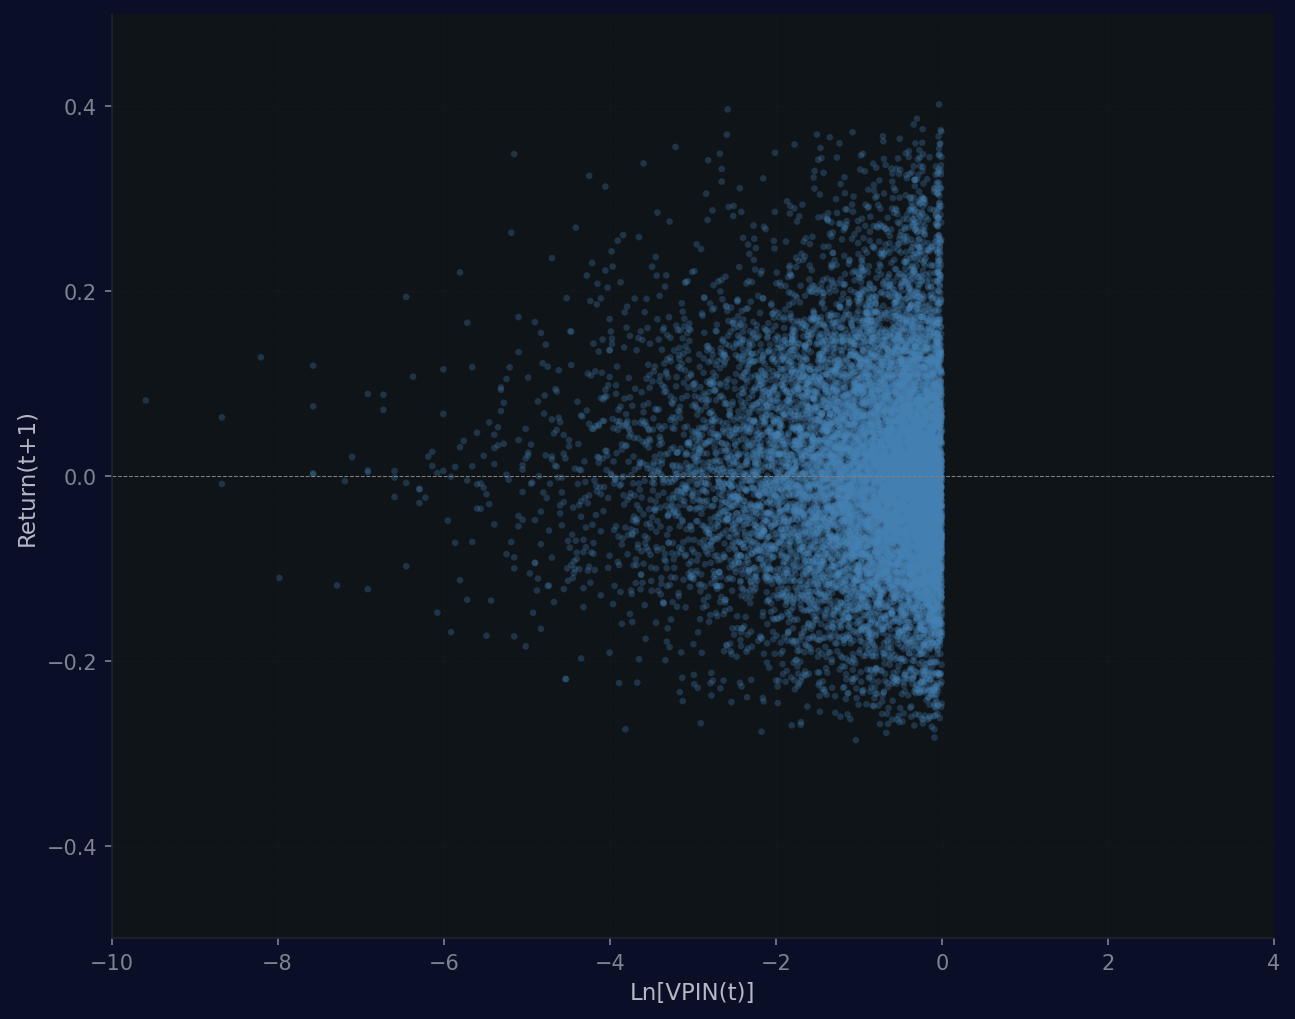

In [404]:

# # Filter out nulls and infinities for plotting
# plot_df = df.filter(
#     pl.col("ln_vpin").is_finite() & pl.col("return_t1").is_not_null()
# )

merged = (

    buckets_from_volume_bars
    .join(metric_from_artificial_buckets, on="end_ts_ns", how="left")
    .filter(
        pl.col("end_ts_ns").is_not_null(),
        pl.col("ln_vpin").is_finite()
    )

).collect()

# Extract as numpy for matplotlib
y = merged["pct_return"].to_numpy()
x = merged["ln_vpin"].to_numpy()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(x, y, alpha=0.3, s=10, c="steelblue", edgecolors="none")

# Adjust axis limits
ax.set_xlim(-10, 4)  # or use 1 for max x-axis
ax.set_ylim(-0.5, 0.5)  # zoom out vertically

ax.set_xlabel("Ln[VPIN(t)]")
ax.set_ylabel("Return(t+1)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.show()

In [405]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_vpin_scatter_bloomberg(x, y, title="Ln(VPIN) vs Return(t+1)"):
    """
    Bloomberg-style scatter plot: ln(VPIN) on x-axis, returns on y-axis.
    Self-contained styling (no global rcParams).
    """

    fig, ax = plt.subplots(figsize=(14, 8))

    # --- Background --------------------------------------------------------
    fig.patch.set_facecolor("#0a0e27")
    ax.set_facecolor("#0f1419")

    # --- Scatter points (cyan) --------------------------------------------
    ax.scatter(
        x,
        y,
        s=14,
        alpha=0.25,
        c="#4ecdc4",
        edgecolors="none",
        antialiased=True,
    )

    # --- Title --------------------------------------------------------------
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color="#ffffff",
        pad=14,
    )

    # --- Axis labels --------------------------------------------------------
    ax.set_xlabel("Ln[VPIN(t)]", fontsize=12, color="#b3b8c4")
    ax.set_ylabel("Return(t+1)", fontsize=12, color="#b3b8c4")

    # Move Y-axis to right (Bloomberg convention)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # --- Tick styling -------------------------------------------------------
    ax.tick_params(axis="x", colors="#7e8391", direction="out", length=5, width=0.8)
    ax.tick_params(axis="y", colors="#7e8391", direction="out", length=5, width=0.8)

    # --- Numeric formatting -------------------------------------------------
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))


    # Adjust axis limits
    ax.set_xlim(-10, 4)  # or use 1 for max x-axis
    ax.set_ylim(-0.5, 0.5)  # zoom out vertically

    # --- Grid (horizontal only) --------------------------------------------
    ax.yaxis.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        color="#1e2332",
        alpha=0.3,
    )
    ax.xaxis.grid(False)

    # --- Spines -------------------------------------------------------------
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.spines["bottom"].set_color("#1e2332")
    ax.spines["right"].set_color("#1e2332")

    # --- Zero return line ---------------------------------------------------
    ax.axhline(
        0,
        color="#ffffff",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25,
    )

    # --- Layout -------------------------------------------------------------
    fig.tight_layout()

    return fig, ax


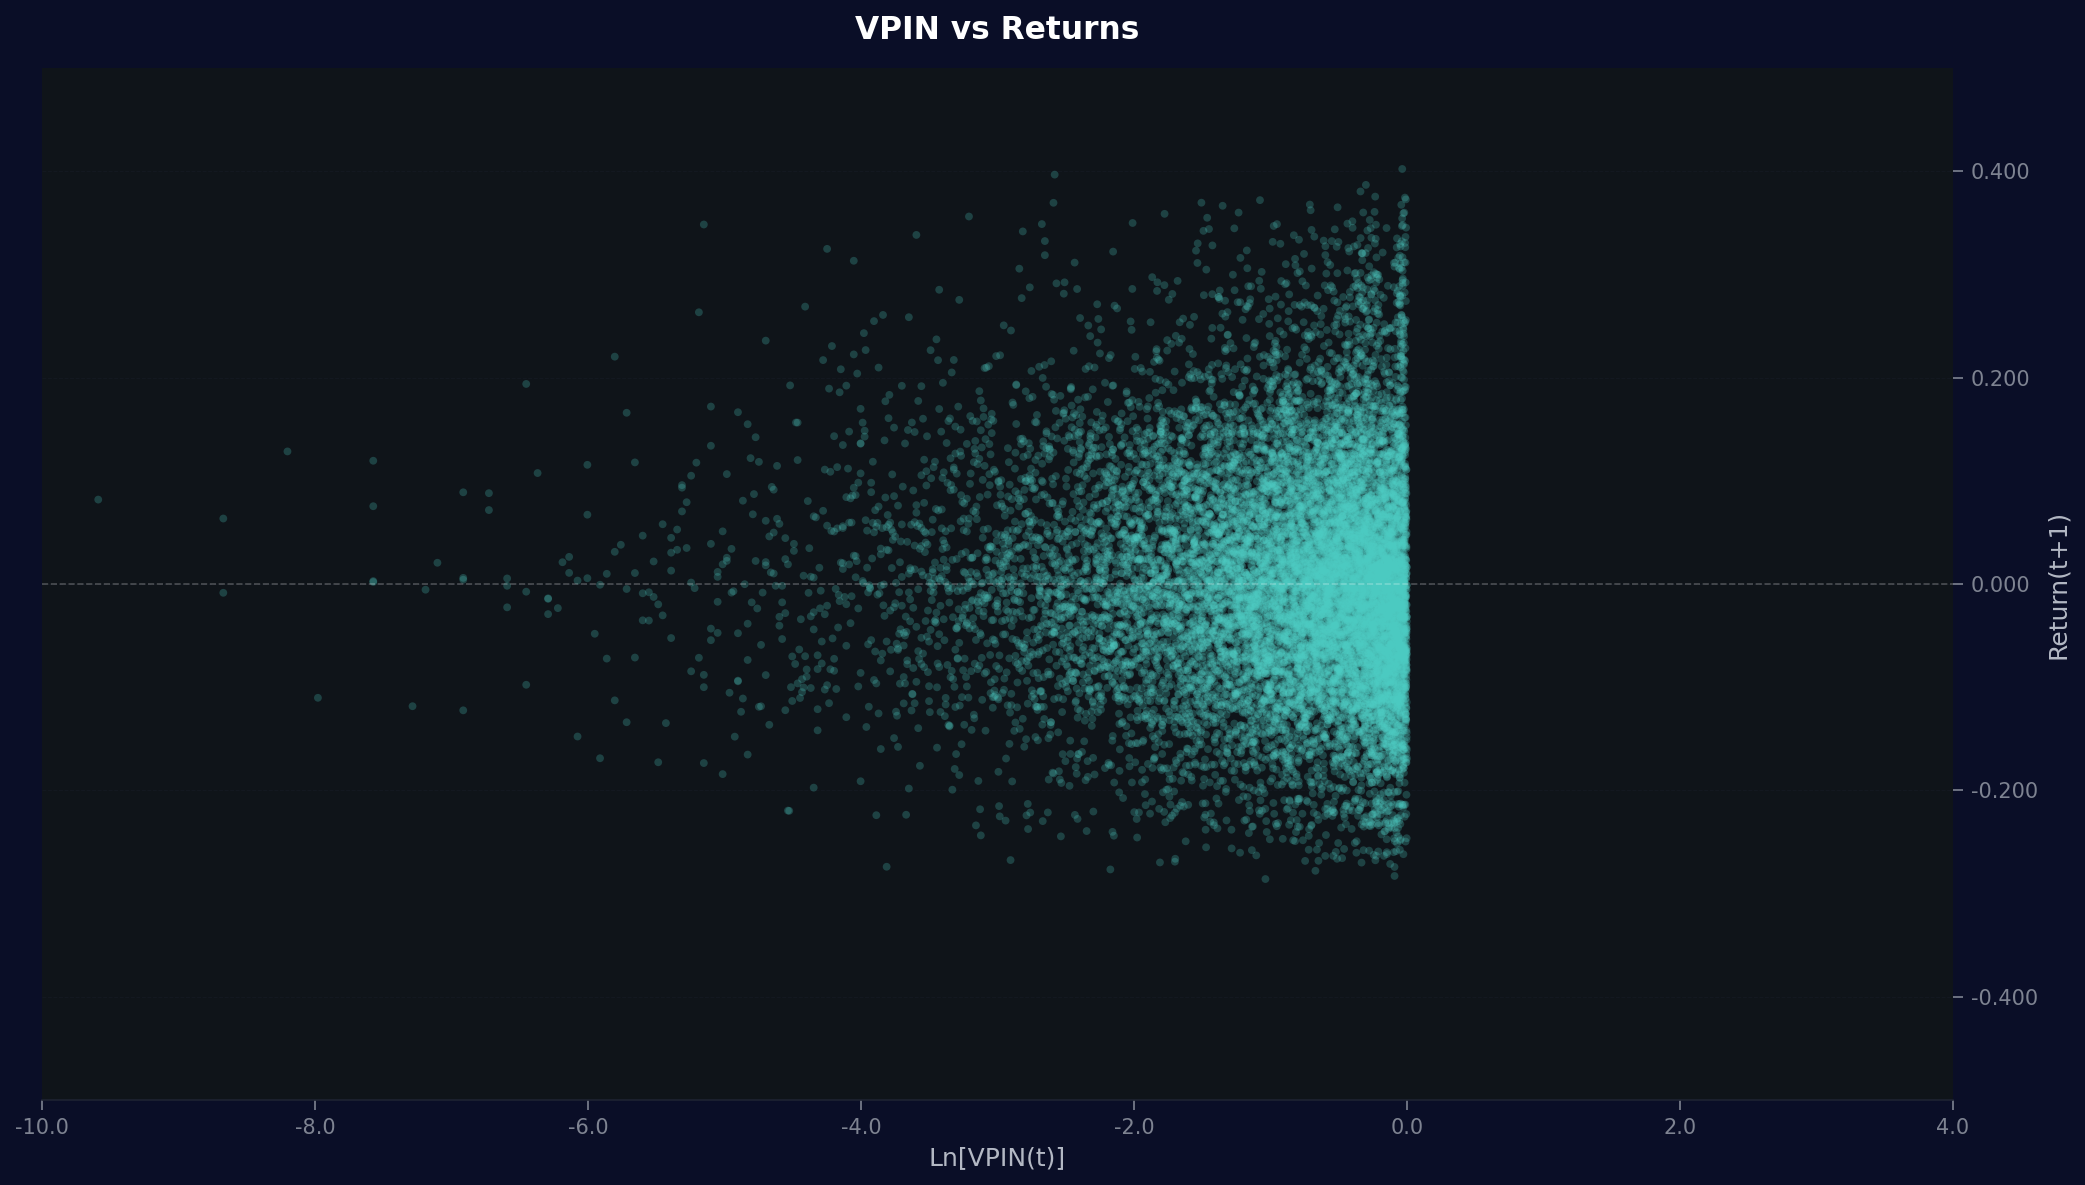

In [406]:
fig, ax = plot_vpin_scatter_bloomberg(
    x=merged["ln_vpin"].to_numpy(),
    y=merged["pct_return"].to_numpy(),
    title="VPIN vs Returns"
)

plt.show()


### Create Cumulative Return Time Series

In [407]:
volume_bar_cumulative_return = (

    VOLUME_BAR_DATA_GLOB
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns(
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    )
    .with_columns(
        pl.col("passive_midprice_delta_log").cum_sum().fill_null(0.0).alias("cumulative_log_return"),
    )
    .with_columns(
        (pl.col("cumulative_log_return") - pl.col("cumulative_log_return").first()).alias("cumulative_log_return"),
    )

)

### Filter By Event: Date Time Frame

In [408]:
# EVENT SPECIFIC

event_volume_bar = (

    volume_bar_cumulative_return
    
).collect()


event_metric = (

    metric_from_artificial_buckets
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    ])
    
).collect()


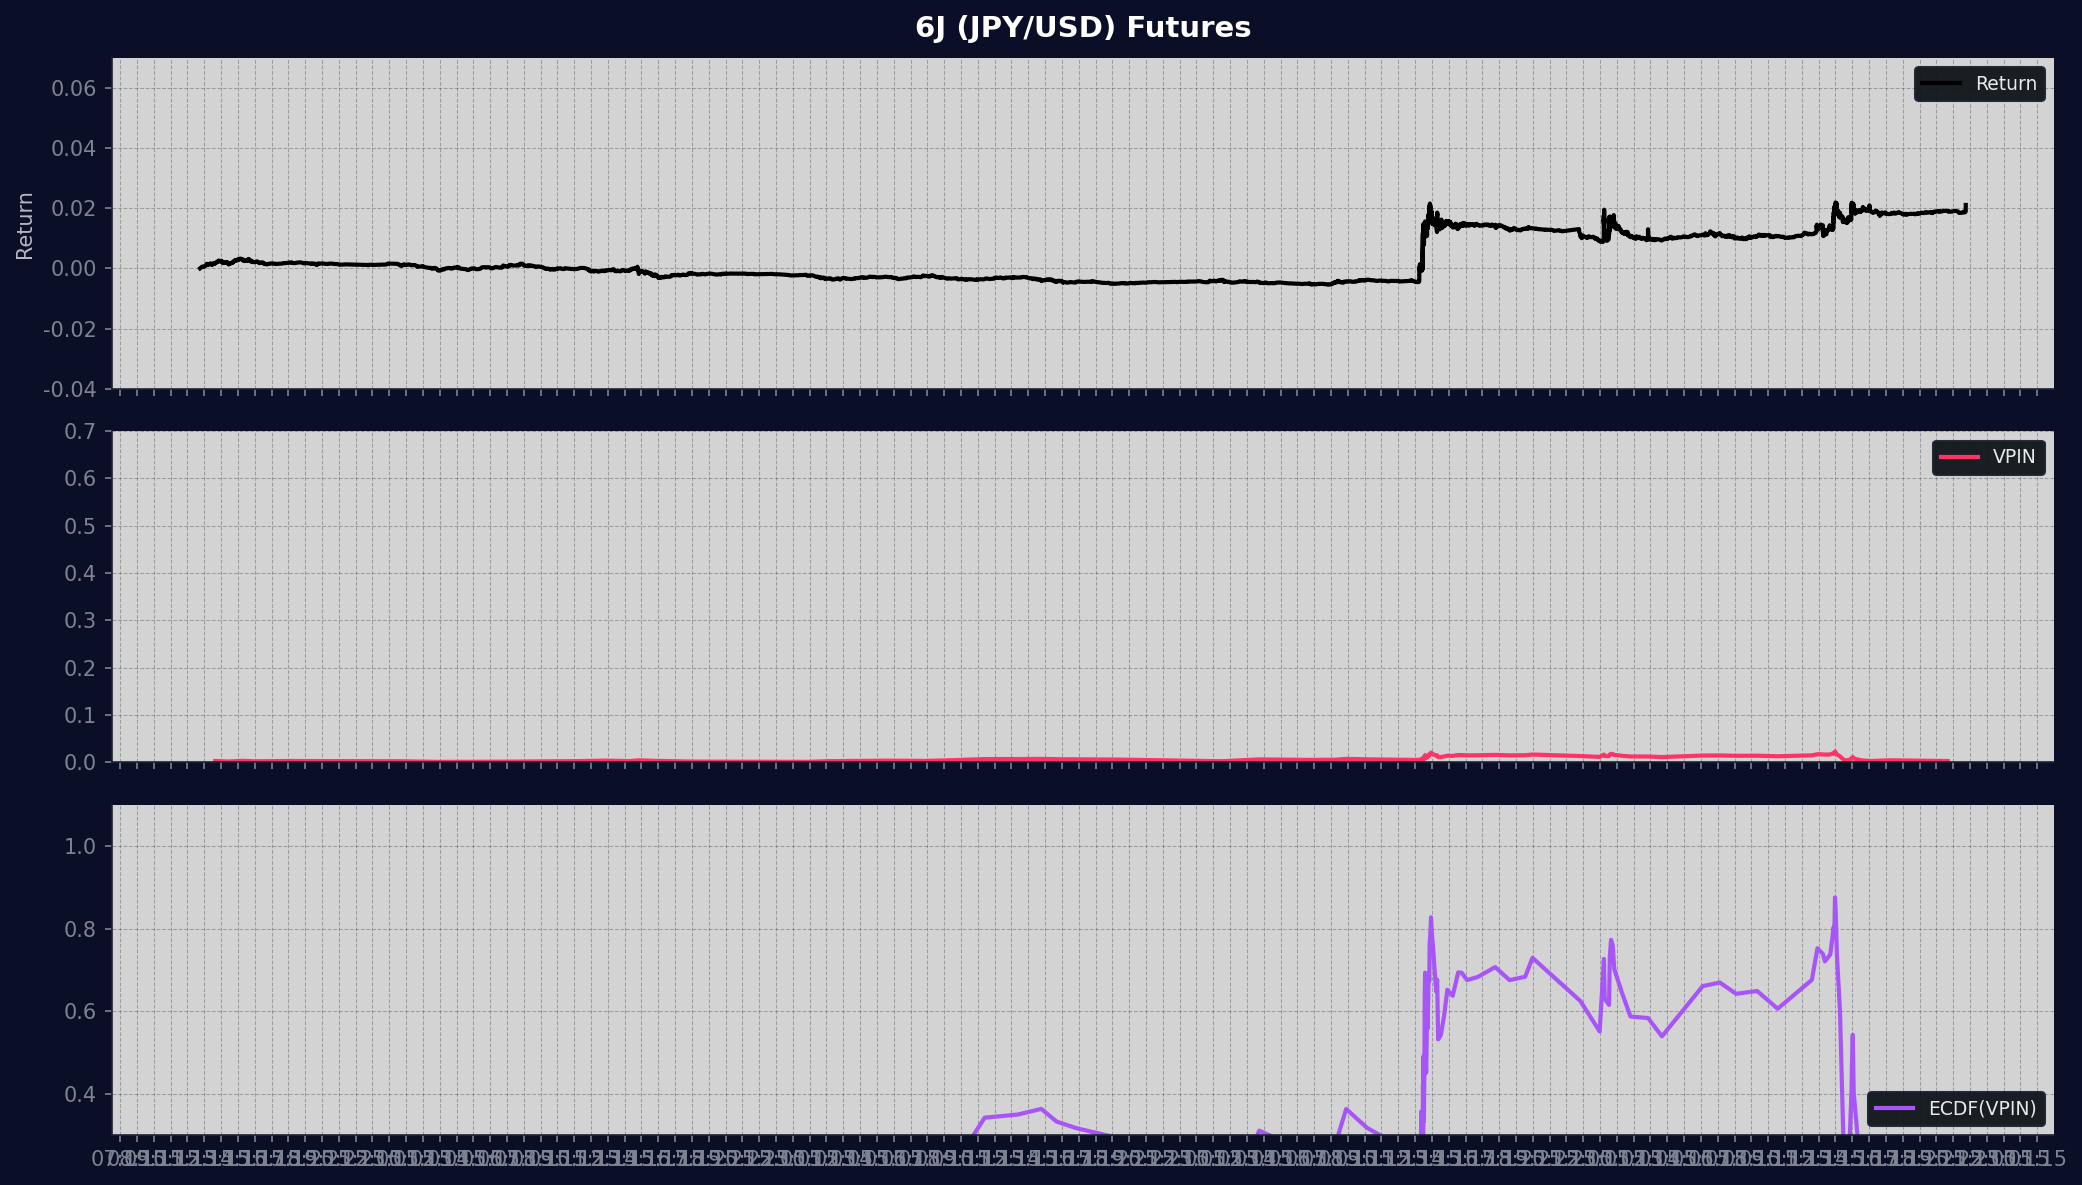

In [409]:

# Apply Bloomberg theme
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0f1419',
    'axes.edgecolor': '#1e2332',
    'axes.labelcolor': '#b3b8c4',
    'axes.titlecolor': '#ffffff',
    'text.color': '#e8eaed',
    'xtick.color': '#7e8391',
    'ytick.color': '#7e8391',
    'grid.color': '#1e2332',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
    'axes.grid': True,
    'axes.axisbelow': True,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'lines.linewidth': 2.0,
})


# Panel 1: Return (declining trend)
times_granular = event_volume_bar["end_ts_ns"] # bar level
returns = event_volume_bar["cumulative_log_return"]

times_metric = event_metric["end_ts_ns"] # metric level
# Panel 2: VPIN and EXPS_VPIN (rising then falling)
vpin = event_metric["normalized__passive_imbalance_abs"]
# exps_vpin = ...

# Panel 3: ECDF functions (rising and stable)
ecdf_vpin = event_metric["ecdf__normalized__passive_imbalance_abs"]
# ecdf_exps = ...

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#0a0e27')
plt.subplots_adjust(hspace=0.05)

# Panel 1: Return
ax1.plot(times_granular, returns, color='#000000', linewidth=2.0) # !!!!
ax1.set_ylabel('Return', fontsize=10, color='#b3b8c4')
ax1.set_title('6J (JPY/USD) Futures', fontsize=14, color='#ffffff', loc='center', pad=10)
ax1.legend(['Return'], loc='upper right', framealpha=0.95, facecolor='#0f1419', 
           edgecolor='#1e2332', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.set_ylim(-0.04, 0.07)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

# Panel 2: VPIN and EXPS_VPIN
ax2.plot(times_metric, vpin, color='#ff3366', linewidth=2.0, linestyle='-') #!!!
# ax2.plot(times_metric, exps_vpin, color='#00ff88', linewidth=2.0, linestyle='--') #!!!
ax2.set_ylabel('', fontsize=10, color='#b3b8c4')
ax2.legend(['VPIN', 'EXPS_VPIN'], loc='upper right', framealpha=0.95, 
           facecolor='#0f1419', edgecolor='#1e2332', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.tick_left()
ax2.yaxis.set_label_position("left")
ax2.set_ylim(0.0, 0.7)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

# Panel 3: ECDF functions
ax3.plot(times_metric, ecdf_vpin, color='#a855f7', linewidth=2.0, linestyle='-') #!!!
# ax3.plot(times_metric, ecdf_exps, color='#ec4899', linewidth=2.0, linestyle='--') #!!!
ax3.set_ylabel('', fontsize=10, color='#b3b8c4')
ax3.set_xlabel('', fontsize=10, color='#b3b8c4')
ax3.legend(['ECDF(VPIN)', 'ECDF(EXPS_VPIN)'], loc='lower right', framealpha=0.95, 
           facecolor='#0f1419', edgecolor='#1e2332', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.yaxis.tick_left()
ax3.yaxis.set_label_position("left")
ax3.set_ylim(0.3, 1.1)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

# Format X-axis with time
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0, ha='center')

# Apply grid to all panels
for ax in [ax1, ax2, ax3]:
    ax.grid(True, color='#1e2332', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_facecolor('#d3d3d3')  # Light gray background matching image

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/crude_oil_analysis.png', dpi=150, facecolor='#0a0e27')
plt.show()

In [410]:
def plot_price_with_metrics(
    main_df: pl.DataFrame,
    main_ts_col: str,
    main_col: str,
    metrics_df: pl.DataFrame,
    metrics_ts_col: str,
    metric_cols: list[str],
    metric_labels: Optional[list[str]] = None,
    main_range: Tuple[Optional[float], Optional[float]] = (None, None),
    metric_range: Tuple[Optional[float], Optional[float]] = (None, None),
    main_range_padding: Tuple[float, float] = (0.0, 0.0),
    metric_range_padding: Tuple[float, float] = (0.0, 0.0),
    title: str = "Main Series vs. Metrics",
    main_label: str = "Main Series",
    main_symbol: str = "",
    main_symbol_prefix: bool = True,
    main_decimal_places: Optional[int] = None,
    show_calculation_guides: bool = True,
    step_lines: bool = True,
    event_a_col: str = "",
    event_a_label: str = "Event A",
    event_b_col: str = "",
    event_b_label: str = "Event B",
    show_time_labels: bool = True,
    rotate_time_labels: Optional[float] = None,
    time_label_interval_hours: Optional[int] = None,
    time_label_format: str = 'auto',
    time_label_max_count: Optional[int] = None,
    figsize: Tuple[int, int] = (16, 10),
) -> Tuple[plt.Figure, Tuple[plt.Axes, plt.Axes]]:
    """
    Plot a main time series with 1-4 metric time series on a dual-axis chart.
    
    Parameters
    ----------
    main_df : pl.DataFrame
        DataFrame containing main series data with nanosecond epoch timestamps.
    main_ts_col : str
        Column name for main series timestamps (nanosecond epoch).
    main_col : str
        Column name for main series values.
    metrics_df : pl.DataFrame
        DataFrame containing metric data with shared timestamps.
    metrics_ts_col : str
        Column name for metric timestamps (nanosecond epoch).
    metric_cols : list[str]
        List of 1-4 column names for metrics to plot.
    metric_labels : list[str], optional
        Display labels for metrics. Defaults to column names.
    main_range : tuple[float | None, float | None]
        Y-axis range for main series: (min, max). Use (None, None) for auto-calculation.
    metric_range : tuple[float | None, float | None]
        Y-axis range for metrics: (min, max). Use (None, None) for auto-calculation.
    main_range_padding : tuple[float, float]
        Absolute padding to add to main range: (lower_bound, upper_bound).
    metric_range_padding : tuple[float, float]
        Absolute padding to add to metric range: (lower_bound, upper_bound).
    title : str
        Chart title.
    main_label : str
        Label for main series in legend.
    main_symbol : str
        Symbol to display with main axis values (e.g., "$", "€", "¥"). Empty string for no symbol.
    main_symbol_prefix : bool
        If True, symbol appears before value. If False, symbol appears after value.
    main_decimal_places : int, optional
        Number of decimal places for main axis. None for auto-determination.
    show_calculation_guides : bool
        Whether to show calculation point markers and vertical interval lines.
    step_lines : bool
        If True, draw step function (horizontal lines held constant).
        If False, draw thin lines connecting calculation points.
    event_a_col : str
        Column name for event A boolean flags. Empty string disables feature.
    event_a_label : str
        Legend label for event A regions.
    event_b_col : str
        Column name for event B boolean flags. Empty string disables feature.
    event_b_label : str
        Legend label for event B regions.
    show_time_labels : bool
        Whether to display time labels on X-axis.
    rotate_time_labels : float, optional
        Rotation angle for time labels in degrees. None uses 0° for horizontal.
        Common values: 0 (horizontal), 45 (diagonal), 90 (vertical).
    time_label_interval_hours : int, optional
        Interval between time labels in hours. None for auto-determination.
    time_label_format : str
        Format for time labels. Options: 'auto', 'time_only', 'date_only', 'full',
        or custom strftime format string (e.g., '%H:%M' or '%Y-%m-%d').
    time_label_max_count : int, optional
        Maximum number of time labels to display. Overrides interval if set.
    figsize : tuple[int, int]
        Figure dimensions.
    
    Returns
    -------
    tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]
        Figure and (main_axis, metrics_axis) tuple.
        
    Notes
    -----
    Time label priority hierarchy:
    1. show_time_labels=False → No labels shown
    2. time_label_max_count → Determines interval to meet max count
    3. time_label_interval_hours → Uses specified interval
    4. Auto-determination → Based on data timespan
    """
    if not 1 <= len(metric_cols) <= 4:
        raise ValueError("metric_cols must contain 1 to 4 column names")
    
    if metric_labels is None:
        metric_labels = metric_cols
    
    if len(metric_labels) != len(metric_cols):
        raise ValueError("metric_labels must match length of metric_cols")
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Metric color palette (up to 4 colors)
    metric_colors = ['#ffd93d', '#ff6b6b', '#a29bfe', '#4ecdc4']
    
    # Event colors
    event_a_color = '#4ecdc4'  # Bright cyan/blue
    event_b_color = '#ff6b9d'  # Bright purple-pink
    
    # Convert main series data
    main_df_plot = main_df.with_columns(
        pl.from_epoch(pl.col(main_ts_col), time_unit="ns").alias("_ts_dt")
    )
    main_pd = main_df_plot.select(["_ts_dt", main_col]).to_pandas()
    main_pd = main_pd.sort_values("_ts_dt")
    
    # Convert metrics data
    metrics_cols_to_select = ["_ts_dt", "start_ts_ns", "end_ts_ns"] + metric_cols
    if event_a_col:
        metrics_cols_to_select.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select.append(event_b_col)
    
    metrics_df_plot = metrics_df.with_columns([
        pl.from_epoch(pl.col(metrics_ts_col), time_unit="ns").alias("_ts_dt"),
        pl.from_epoch(pl.col("start_ts_ns"), time_unit="ns").alias("_start_dt"),
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("_end_dt"),
    ])
    
    metrics_cols_to_select_final = ["_ts_dt", "_start_dt", "_end_dt"] + metric_cols
    if event_a_col:
        metrics_cols_to_select_final.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select_final.append(event_b_col)
    
    metrics_pd = metrics_df_plot.select(metrics_cols_to_select_final).to_pandas()
    metrics_pd = metrics_pd.sort_values("_ts_dt")
    
    # Calculate data timespan for auto-formatting
    time_min = main_pd["_ts_dt"].min()
    time_max = main_pd["_ts_dt"].max()
    timespan_hours = (time_max - time_min).total_seconds() / 3600
    
    # Calculate main range if needed
    if main_range[0] is None or main_range[1] is None:
        main_min = main_pd[main_col].min()
        main_max = main_pd[main_col].max()
        main_range = (main_min, main_max)
    
    # Apply padding to main range
    final_main_min = main_range[0] - main_range_padding[0]
    final_main_max = main_range[1] + main_range_padding[1]
    
    # Calculate metric range if needed
    if metric_range[0] is None or metric_range[1] is None:
        all_metric_values = []
        for col in metric_cols:
            all_metric_values.extend(metrics_pd[col].values)
        metric_min = min(all_metric_values)
        metric_max = max(all_metric_values)
        metric_range = (metric_min, metric_max)
    
    # Apply padding to metric range
    final_metric_min = metric_range[0] - metric_range_padding[0]
    final_metric_max = metric_range[1] + metric_range_padding[1]
    
    # Auto-determine decimal places for main axis if not specified
    if main_decimal_places is None:
        main_data_range = main_range[1] - main_range[0]
        if main_data_range >= 100:
            main_decimal_places = 0
        elif main_data_range >= 10:
            main_decimal_places = 1
        elif main_data_range >= 1:
            main_decimal_places = 2
        elif main_data_range >= 0.1:
            main_decimal_places = 3
        elif main_data_range >= 0.01:
            main_decimal_places = 4
        else:
            main_decimal_places = 5
    
    # Build list of event time ranges where lines should be discontinuous
    event_ranges = []
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    
    # Helper function to check if a timestamp is within any event range
    def is_in_event(timestamp):
        for start, end in event_ranges:
            if start <= timestamp <= end:
                return True
        return False
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Track if events are actually shown for legend
    event_a_shown = False
    event_b_shown = False
    
    # Draw event A regions (lowest z-order)
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_a_color,
                alpha=0.3,
                zorder=0
            )
            event_a_shown = True
    
    # Draw event B regions (lowest z-order)
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_b_color,
                alpha=0.3,
                zorder=0
            )
            event_b_shown = True
    
    # Left Y-axis: Main series (with discontinuities during events)
    if len(event_ranges) > 0:
        # Split main data into segments avoiding event periods
        current_segment_times = []
        current_segment_values = []
        
        for i, row in main_pd.iterrows():
            timestamp = row["_ts_dt"]
            value = row[main_col]
            
            if is_in_event(timestamp):
                # If we have accumulated data, plot it
                if len(current_segment_times) > 0:
                    ax1.plot(
                        current_segment_times,
                        current_segment_values,
                        color='#00d4aa',
                        linewidth=2.5,
                        zorder=2
                    )
                    current_segment_times = []
                    current_segment_values = []
            else:
                current_segment_times.append(timestamp)
                current_segment_values.append(value)
        
        # Plot any remaining segment
        if len(current_segment_times) > 0:
            ax1.plot(
                current_segment_times,
                current_segment_values,
                color='#00d4aa',
                linewidth=2.5,
                label=main_label,
                zorder=2
            )
    else:
        # No events, plot continuously
        ax1.plot(
            main_pd["_ts_dt"],
            main_pd[main_col],
            color='#00d4aa',
            linewidth=2.5,
            label=main_label,
            zorder=2
        )
    
    ax1.set_ylabel(main_label, fontsize=11, color='#00d4aa')
    ax1.tick_params(axis='y', labelcolor='#00d4aa')
    ax1.set_ylim(final_main_min, final_main_max)
    
    # Format main axis with symbol and decimal places
    def format_main_axis(x, p):
        formatted_value = f'{x:,.{main_decimal_places}f}'
        if main_symbol:
            if main_symbol_prefix:
                return f'{main_symbol}{formatted_value}'
            else:
                return f'{formatted_value}{main_symbol}'
        return formatted_value
    
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_main_axis))
    
    # Right Y-axis: Metrics
    ax2 = ax1.twinx()
    
    metric_times = metrics_pd["_ts_dt"].values
    main_end_time = main_pd["_ts_dt"].iloc[-1]
    
    legend_lines = []
    legend_labels = []
    
    for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
        color = metric_colors[i]
        metric_values = metrics_pd[col].values
        
        if step_lines:
            # Plot step function with discontinuities during events
            for j in range(len(metric_times) - 1):
                start_time = metric_times[j]
                end_time = metric_times[j + 1]
                value = metric_values[j]
                
                # Check if this segment overlaps with any event
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (end_time <= event_start or start_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        value,
                        start_time,
                        end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
            
            # Extend last value to end of main data if not in event
            if len(metric_times) > 0:
                last_time = metric_times[-1]
                last_value = metric_values[-1]
                
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (main_end_time <= event_start or last_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        last_value,
                        last_time,
                        main_end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
        else:
            # Plot thin lines with discontinuities during events
            if len(event_ranges) > 0:
                current_segment_times = []
                current_segment_values = []
                
                for j in range(len(metric_times)):
                    timestamp = metric_times[j]
                    value = metric_values[j]
                    
                    if is_in_event(timestamp):
                        # Plot accumulated segment
                        if len(current_segment_times) > 0:
                            ax2.plot(
                                current_segment_times,
                                current_segment_values,
                                color=color,
                                linewidth=1.0,
                                zorder=3
                            )
                            current_segment_times = []
                            current_segment_values = []
                    else:
                        current_segment_times.append(timestamp)
                        current_segment_values.append(value)
                
                # Plot remaining segment
                if len(current_segment_times) > 0:
                    ax2.plot(
                        current_segment_times,
                        current_segment_values,
                        color=color,
                        linewidth=1.0,
                        zorder=3
                    )
            else:
                # No events, plot continuously
                ax2.plot(
                    metric_times,
                    metric_values,
                    color=color,
                    linewidth=1.0,
                    zorder=3
                )
        
        # Add calculation point markers if enabled (always show, even during events)
        if show_calculation_guides:
            ax2.scatter(
                metric_times,
                metric_values,
                color=color,
                s=60,
                zorder=4,
                edgecolors='#ffffff',
                linewidths=1.0
            )
        
        # Build legend entry
        legend_lines.append(plt.Line2D([0], [0], color=color, linewidth=2.0 if step_lines else 1.0))
        legend_labels.append(label)
    
    # Add vertical calculation interval lines if enabled
    if show_calculation_guides:
        for ptime in metric_times:
            ax1.axvline(
                x=ptime,
                color="#ffffff",
                alpha=0.5,
                linestyle=':',
                linewidth=1.0,
                zorder=1
            )
    
    # Configure right Y-axis
    ax2.set_ylabel('Metric Value', fontsize=11, color='#ffd93d')
    ax2.tick_params(axis='y', labelcolor='#ffd93d')
    ax2.set_ylim(final_metric_min, final_metric_max)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    
    # Add reference lines for metric range (only at meaningful boundaries)
    metric_data_range = metric_range[1] - metric_range[0]
    if abs(metric_data_range - 2.0) < 0.1:  # Close to -1 to 1 range
        ax2.axhline(y=-1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    elif abs(metric_data_range - 1.0) < 0.1:  # Close to 0 to 1 range
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0.5, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    else:
        # For custom ranges, add reference at midpoint
        midpoint = (metric_range[0] + metric_range[1]) / 2
        ax2.axhline(y=metric_range[0], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=midpoint, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=metric_range[1], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    
    # Configure X-axis time labels
    if show_time_labels:
        # Determine format string
        if time_label_format == 'auto':
            if timespan_hours < 6:
                format_str = '%H:%M'
            elif timespan_hours < 48:
                format_str = '%H:%M\n%m/%d'
            elif timespan_hours < 168:  # 1 week
                format_str = '%m/%d\n%H:%M'
            else:
                format_str = '%m/%d'
        elif time_label_format == 'time_only':
            format_str = '%H:%M'
        elif time_label_format == 'date_only':
            format_str = '%m/%d'
        elif time_label_format == 'full':
            format_str = '%H:%M\n%m/%d'
        else:
            # Custom format string
            format_str = time_label_format
        
        # Determine interval
        if time_label_max_count is not None:
            # Calculate interval to meet max count constraint
            calculated_interval_hours = max(1, int(timespan_hours / time_label_max_count))
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=calculated_interval_hours))
        elif time_label_interval_hours is not None:
            # Use specified interval
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=time_label_interval_hours))
        else:
            # Auto-determine interval based on timespan
            if timespan_hours < 6:
                interval = 1
            elif timespan_hours < 24:
                interval = 3
            elif timespan_hours < 48:
                interval = 6
            elif timespan_hours < 168:
                interval = 12
            else:
                interval = 24
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
        
        # Set formatter
        ax1.xaxis.set_major_formatter(mdates.DateFormatter(format_str))
        
        # Apply rotation
        rotation_angle = rotate_time_labels if rotate_time_labels is not None else 0
        ha = 'right' if rotation_angle > 0 else 'center'
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=rotation_angle, ha=ha)
    else:
        # Hide time labels
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
    
    # Title
    ax1.set_title(title, fontsize=16, weight='bold', color='#ffffff', pad=20)
    
    # Style spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color('#00d4aa')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_color('#1e2332')
    ax2.spines['right'].set_color('#ffd93d')
    ax2.spines['right'].set_linewidth(1.5)
    
    # Build complete legend
    main_line = plt.Line2D([0], [0], color='#00d4aa', linewidth=2.5)
    all_lines = [main_line] + legend_lines
    all_labels = [main_label] + legend_labels
    
    # Add event patches to legend if they were shown
    if event_a_shown:
        event_a_patch = plt.Rectangle((0, 0), 1, 1, fc=event_a_color, alpha=0.3)
        all_lines.append(event_a_patch)
        all_labels.append(event_a_label)
    
    if event_b_shown:
        event_b_patch = plt.Rectangle((0, 0), 1, 1, fc=event_b_color, alpha=0.3)
        all_lines.append(event_b_patch)
        all_labels.append(event_b_label)
    
    if show_calculation_guides:
        calc_marker = plt.Line2D(
            [0], [0],
            marker='o',
            color='#ffffff',
            linewidth=0,
            markersize=8,
            markerfacecolor='#ffd93d',
            markeredgecolor='#ffffff',
            markeredgewidth=1.0
        )
        interval_line = plt.Line2D(
            [0], [0],
            color='#ffffff',
            alpha=0.5,
            linestyle=':',
            linewidth=1.0
        )
        all_lines.extend([calc_marker, interval_line])
        all_labels.extend(['Calculation Point', 'Calculation Interval'])
    
    # Legend outside plot area
    ax1.legend(
        all_lines,
        all_labels,
        loc='upper left',
        bbox_to_anchor=(1.08, 1.0),
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9
    )
    
    # Disable grid on secondary axis
    ax2.grid(False)
    
    plt.tight_layout()
    
    return fig, (ax1, ax2)
"""

Priority hierarchy for time labels:

show_time_labels=False → No labels displayed at all
time_label_max_count → Calculates interval to show exactly this many labels
time_label_interval_hours → Uses the specified hour interval
Auto-determination → Based on data timespan (default behavior)

Usage examples:

"""

# # Default auto behavior - no parameters needed
# fig, axes = plot_price_with_metrics(
#     main_df=vwap,
#     main_ts_col="ts_recv",
#     main_col="Price",
#     metrics_df=metrics_event,
#     metrics_ts_col="end_ts_ns",
#     metric_cols=["ratio"],
# )

# # Hide time labels completely
# fig, axes = plot_price_with_metrics(..., show_time_labels=False)

# # Show max 10 labels with 45° rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_max_count=10,
#     rotate_time_labels=45,
# )

# # Manual interval: every 3 hours, time only, vertical text
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_interval_hours=3,
#     time_label_format='time_only',
#     rotate_time_labels=90,
# )

# # Custom format with no rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_format='%Y-%m-%d %H:%M',
#     rotate_time_labels=0,
# )

'\n\nPriority hierarchy for time labels:\n\nshow_time_labels=False → No labels displayed at all\ntime_label_max_count → Calculates interval to show exactly this many labels\ntime_label_interval_hours → Uses the specified hour interval\nAuto-determination → Based on data timespan (default behavior)\n\nUsage examples:\n\n'

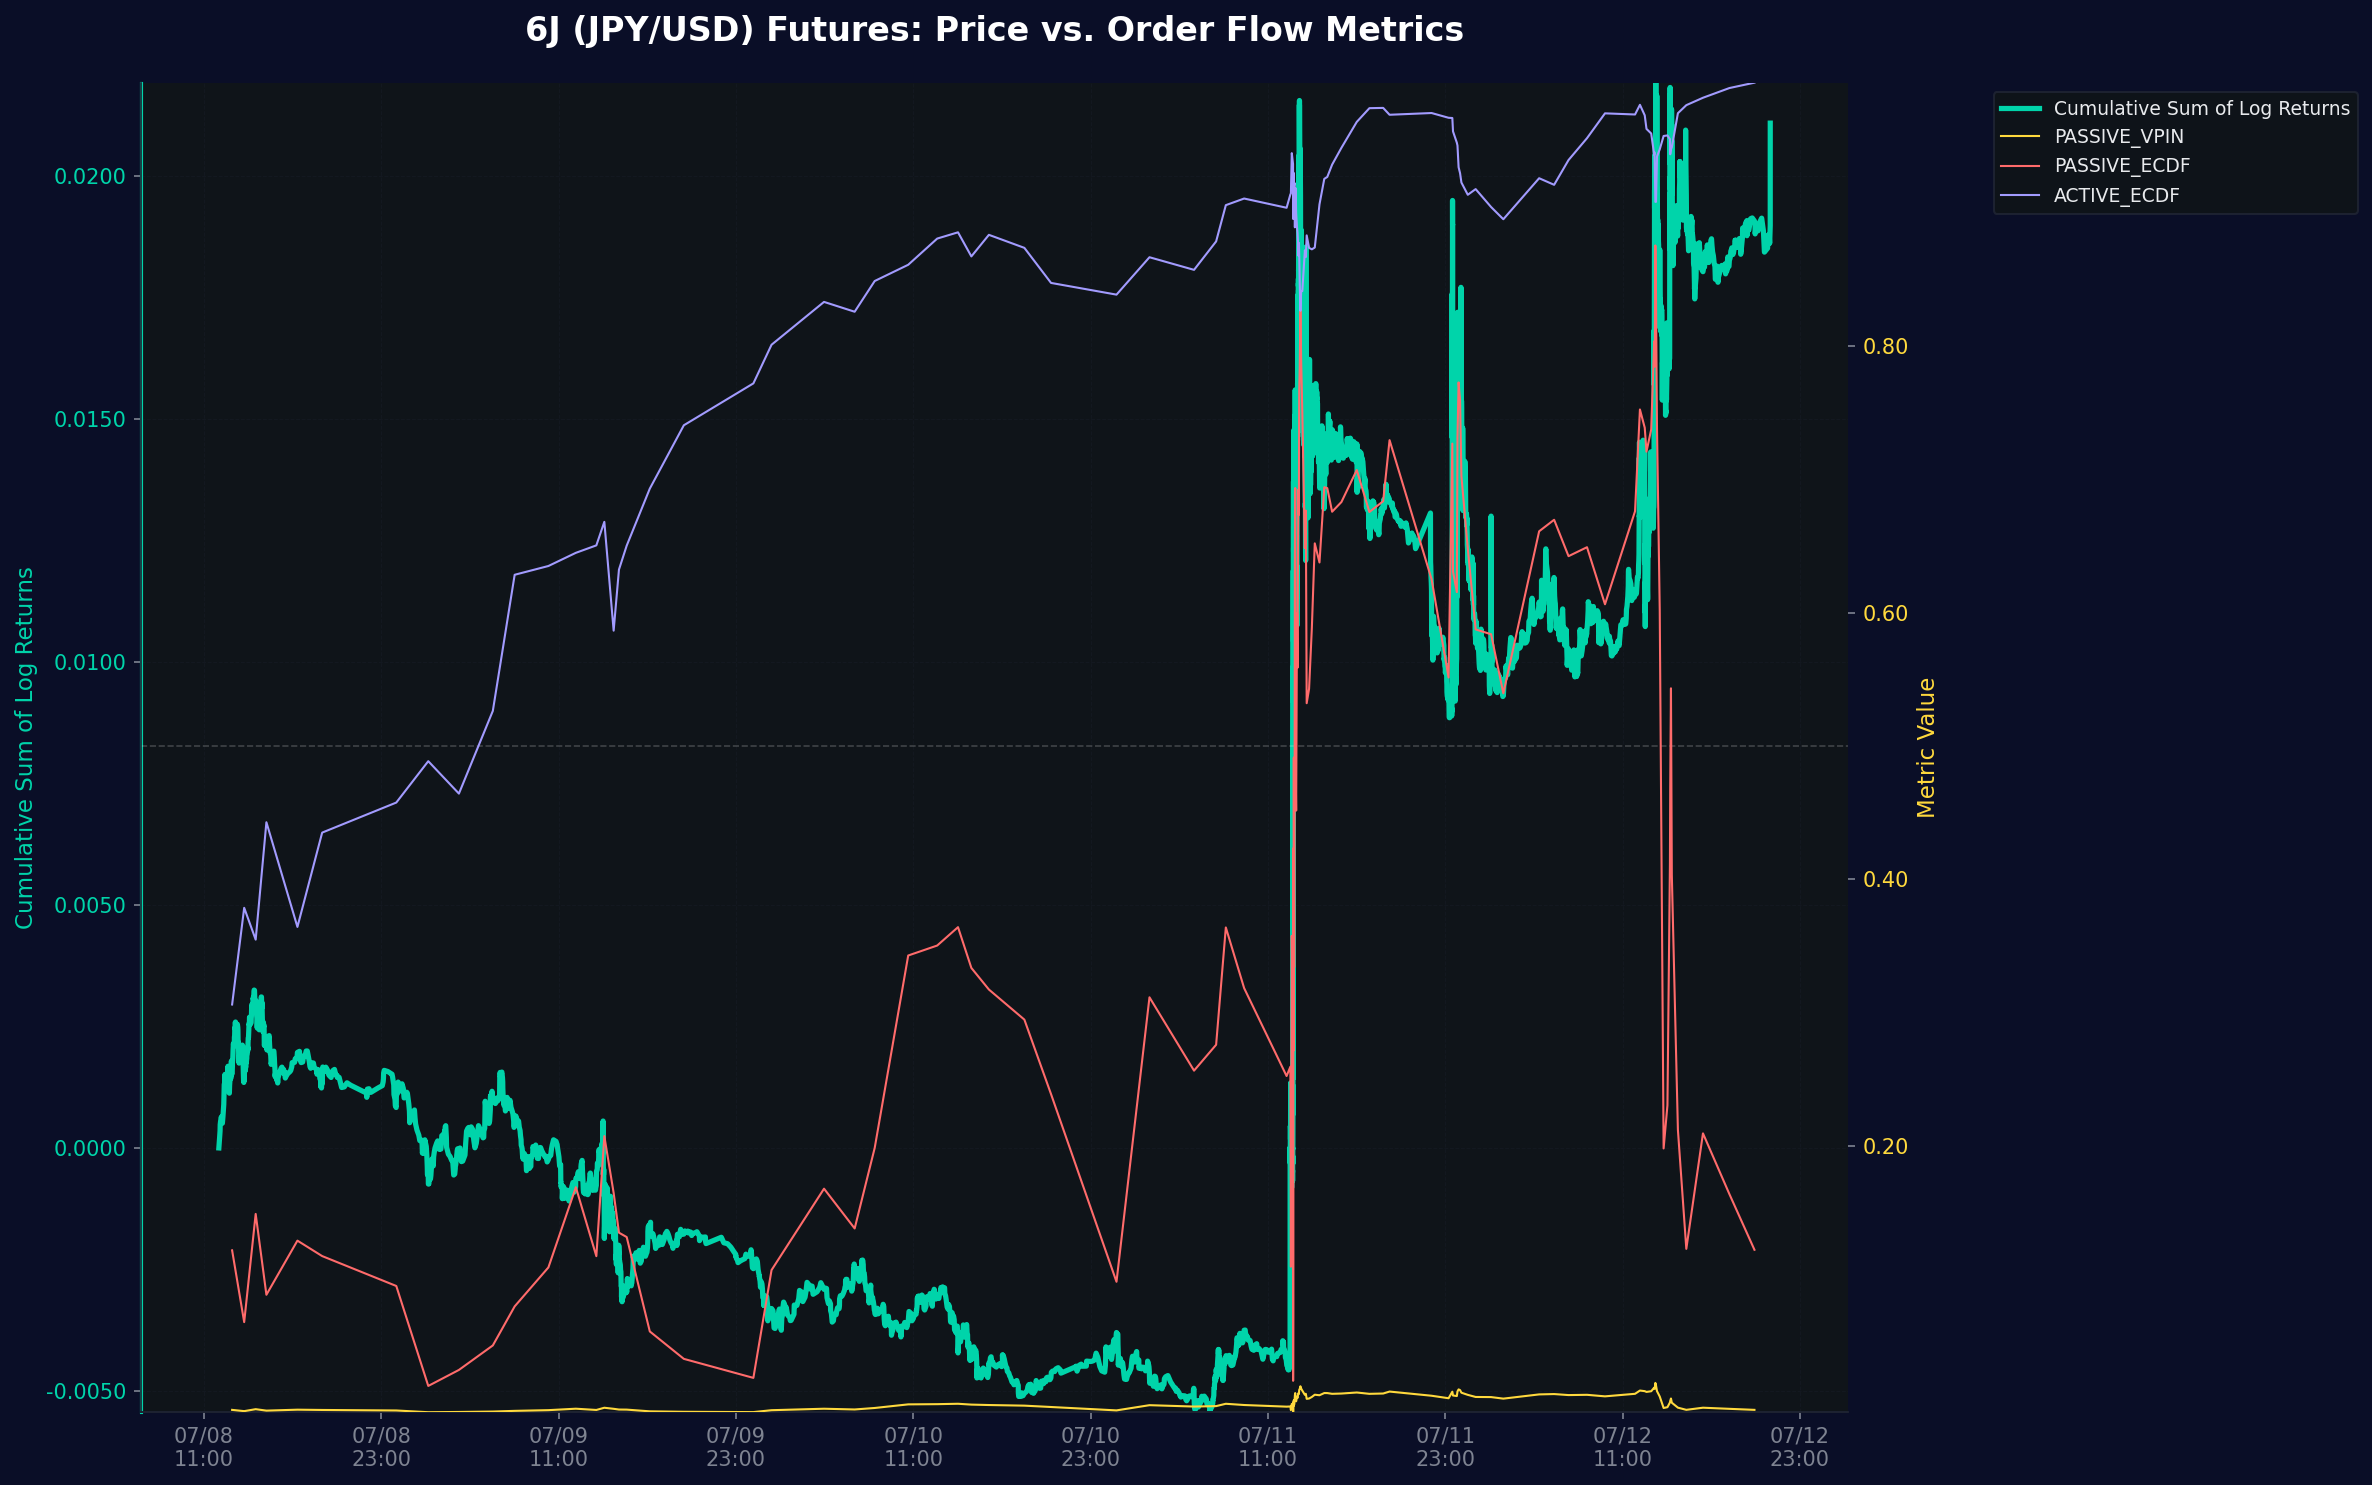

In [411]:
"""

Priority hierarchy for time labels:

show_time_labels=False → No labels displayed at all
time_label_max_count → Calculates interval to show exactly this many labels
time_label_interval_hours → Uses the specified hour interval
Auto-determination → Based on data timespan (default behavior)

Usage examples:

"""

# # Default auto behavior - no parameters needed
fig, axes = plot_price_with_metrics(
    main_df=event_volume_bar,
    main_ts_col="end_ts_ns",
    main_col="cumulative_log_return",
    main_label="Cumulative Sum of Log Returns",

    metrics_df=event_metric,
    metrics_ts_col="end_ts_ns",
    metric_cols=["normalized__passive_imbalance_abs", "ecdf__normalized__passive_imbalance_abs", "ecdf__normalized__active_imbalance_abs"],
    metric_labels=["PASSIVE_VPIN", "PASSIVE_ECDF", "ACTIVE_ECDF"],

    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",

    event_a_col="contract_roll_any",
    event_a_label="CONTRACT ROLL",

    event_b_col="gap_return_any",
    event_b_label="MARKET CLOSED",

    show_calculation_guides=False,
    step_lines=False,
)

# # Hide time labels completely
# fig, axes = plot_price_with_metrics(..., show_time_labels=False)

# # Show max 10 labels with 45° rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_max_count=10,
#     rotate_time_labels=45,
# )

# # Manual interval: every 3 hours, time only, vertical text
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_interval_hours=3,
#     time_label_format='time_only',
#     rotate_time_labels=90,
# )

# # Custom format with no rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_format='%Y-%m-%d %H:%M',
#     rotate_time_labels=0,
# )

### Cumulative Daily Volume

In [412]:


# ============================================================================
# [START] - Import Filters
# ============================================================================

# # Data files to glob for processing
# DATA_GLOB = pl.scan_parquet(str(PARQUET_DIR / request_id / "*.parquet"))

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2022__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2023__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2024__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
daily_seasonality = (

    # 0) Glob across all files in data directory
    DATA_GLOB
    
    # 1) Select only needed columns FIRST (reduces data volume)
    .select([
        "ts_recv",
        "price",
        "size",
        "side",
        "sequence",
        "instrument_id",
    ])

    # 2.) Convert to physical int representation (just stripping data, saved as int64 in Parquet file)
    .with_columns([
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
    ])
    
    # 4) Add temporal grouping columns for aggregation
    .with_columns([
        pl.from_epoch("ts_recv", time_unit="ns").alias("timestamp"),
    ])
    .with_columns([
        pl.col("timestamp").dt.date().alias("date"),
        pl.col("timestamp").dt.hour().alias("hour"),
        pl.col("timestamp").dt.minute().alias("minute")
    ])

)

# Now perform the aggregation
volume_profile = (
    daily_seasonality
    # Group by date, hour, minute - sum volume for each minute of each day
    .group_by(["date", "hour", "minute"])
    .agg([
        pl.col("size").sum().alias("minute_volume")
    ])
    
    # Average across all days to get typical minute volume
    .group_by(["hour", "minute"])
    .agg([
        pl.col("minute_volume").mean().alias("avg_minute_volume")
    ])
    
    # Sort by time
    .sort(["hour", "minute"])
    
    # Create cumulative sum
    .with_columns([
    pl.col("avg_minute_volume").cum_sum().alias("cumulative_daily_avg_volume"),
    (pl.col("hour").cast(pl.Utf8).str.pad_start(2, "0") + ":" + 
     pl.col("minute").cast(pl.Utf8).str.pad_start(2, "0")).alias("time")
])
)

# Verify the result
print(volume_profile.limit(5).collect())



shape: (5, 5)
┌──────┬────────┬───────────────────┬─────────────────────────────┬───────┐
│ hour ┆ minute ┆ avg_minute_volume ┆ cumulative_daily_avg_volume ┆ time  │
│ ---  ┆ ---    ┆ ---               ┆ ---                         ┆ ---   │
│ i8   ┆ i8     ┆ f64               ┆ f64                         ┆ str   │
╞══════╪════════╪═══════════════════╪═════════════════════════════╪═══════╡
│ 0    ┆ 0      ┆ 269.306598        ┆ 269.306598                  ┆ 00:00 │
│ 0    ┆ 1      ┆ 211.630491        ┆ 480.937089                  ┆ 00:01 │
│ 0    ┆ 2      ┆ 166.761658        ┆ 647.698747                  ┆ 00:02 │
│ 0    ┆ 3      ┆ 139.529793        ┆ 787.228539                  ┆ 00:03 │
│ 0    ┆ 4      ┆ 121.83053         ┆ 909.05907                   ┆ 00:04 │
└──────┴────────┴───────────────────┴─────────────────────────────┴───────┘


In [413]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd


def plot_cumulative_volume(
    df,
    time_col: str = "time",
    cumvol_col: str = "cumulative_daily_avg_volume",
    title: str | None = None,
):
    """
    Plot cumulative volume over the trading day with styled formatting.

    Y-axis: cumulative volume (comma formatting)
    X-axis: HH:MM time of day
    """

    # Convert Polars to pandas if needed
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()

    if time_col not in df.columns:
        raise KeyError(f"Column '{time_col}' not found in DataFrame.")
    if cumvol_col not in df.columns:
        raise KeyError(f"Column '{cumvol_col}' not found in DataFrame.")

    # Convert "HH:MM" string → datetime
    time_dt = pd.to_datetime(df[time_col], format="%H:%M")

    # ---------- Styling ----------
    plt.style.use("default")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.labelsize": 12,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        }
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    # Line plot
    ax.plot(
        time_dt,
        df[cumvol_col],
        linewidth=1.6,
        color="black"
    )

    ax.set_xlabel("Time of Day (UTC)")
    ax.set_ylabel("Cumulative Volume (contracts traded)")

    if title is not None:
        ax.set_title(title, pad=12)

    # X-axis formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    # Y-axis formatting with commas
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

    # Grid styling
    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        color="#CCCCCC",
        alpha=0.6,
    )

    fig.tight_layout()
    return fig, ax


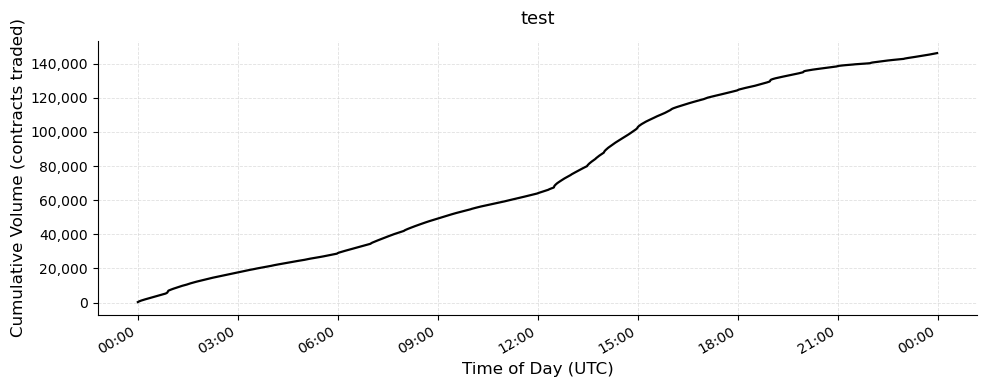

In [414]:

fig, axes = plot_cumulative_volume(
    df=volume_profile.collect(),
    title="test"
)
plt.show()

In [415]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd


def _apply_bloomberg_theme():
    """Apply Bloomberg-style dark theme to matplotlib rcParams."""
    plt.rcParams.update(
        {
            # Figure / axes
            "figure.facecolor": "#0a0e27",
            "figure.edgecolor": "#0a0e27",
            "axes.facecolor": "#0f1419",
            "axes.edgecolor": "#1e2332",
            "axes.labelcolor": "#b3b8c4",
            "axes.titlecolor": "#ffffff",
            "text.color": "#e8eaed",
            # Ticks
            "xtick.color": "#7e8391",
            "ytick.color": "#7e8391",
            "xtick.direction": "out",
            "ytick.direction": "out",
            # Grid
            "grid.color": "#1e2332",
            "grid.linestyle": "--",
            "grid.linewidth": 0.5,
            "grid.alpha": 0.3,
            "axes.grid": True,
            "axes.axisbelow": True,
            # Font / lines
            "font.family": "sans-serif",
            "font.size": 10,
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "lines.linewidth": 2.5,
            # DPI
            "figure.dpi": 150,
        }
    )


def _volume_formatter(x, pos):
    """Format volume ticks with K/M abbreviations and commas for small values."""
    abs_x = abs(x)
    if abs_x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs_x >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:,.0f}"


def plot_cumulative_volume_bloomberg(
    df,
    time_col: str = "time",
    cumvol_col: str = "cumulative_daily_avg_volume",
    title: str | None = None,
):
    """
    Bloomberg-style cumulative volume intraday time series.

    - X-axis: time of day (HH:MM)
    - Y-axis (right): cumulative volume, K/M formatted
    """

    # Convert Polars to pandas if needed
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()

    if time_col not in df.columns:
        raise KeyError(f"Column '{time_col}' not found in DataFrame.")
    if cumvol_col not in df.columns:
        raise KeyError(f"Column '{cumvol_col}' not found in DataFrame.")

    # Parse HH:MM into datetime (date component arbitrary)
    time_dt = pd.to_datetime(df[time_col], format="%H:%M")

    # Apply theme
    _apply_bloomberg_theme()

    # Figure / axis
    fig, ax = plt.subplots(figsize=(14, 8))

    # Main line (use primary teal color)
    ax.plot(
        time_dt,
        df[cumvol_col],
        color="#00d4aa",
        antialiased=True,
    )

    # Titles / labels
    if title is not None:
        ax.set_title(title, pad=14)
    ax.set_xlabel("Time of Day (UTC)")
    ax.set_ylabel("Cumulative Volume (contracts)")

    # Right-side Y-axis (Bloomberg convention)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Axes / spines
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    # Keep bottom/right but subtle
    ax.spines["bottom"].set_color("#1e2332")
    ax.spines["right"].set_color("#1e2332")

    # Grid: horizontal only
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

    # Tick params
    ax.tick_params(axis="both", which="both", length=4, width=0.8)

    # X-axis time formatting (intraday HH:MM)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # Y-axis volume formatting
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_volume_formatter))

    # Tight layout
    fig.tight_layout()

    return fig, ax


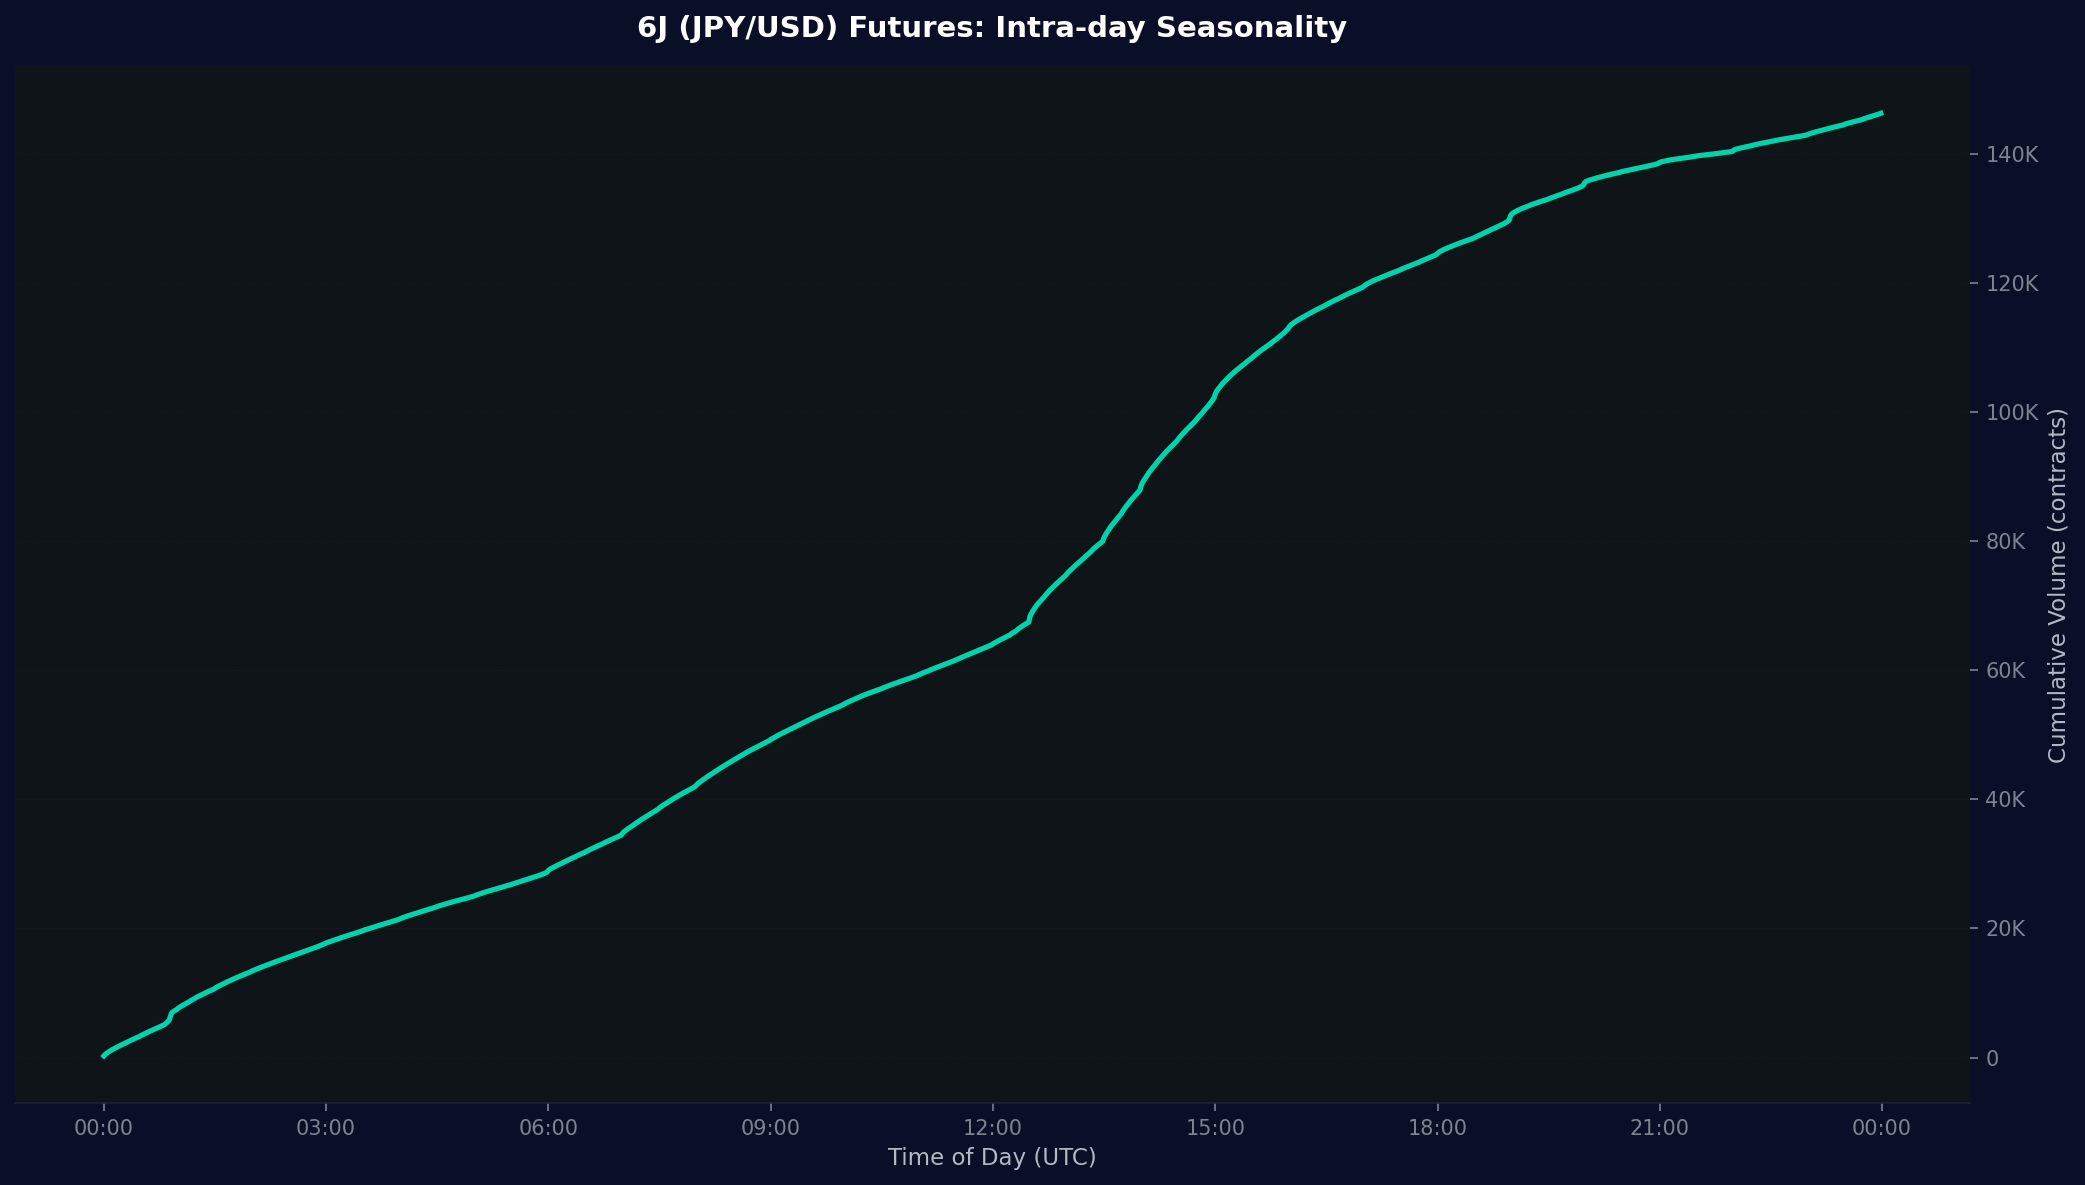

In [416]:
# Example usage

fig, ax = plot_cumulative_volume_bloomberg(
    df=volume_profile.collect(),
    title="6J (JPY/USD) Futures: Intra-day Seasonality"
)

plt.show()
